Dataset:

     Outlook Temperature Humidity    Wind PlayTennis
0      Sunny         Hot     High    Weak         No
1      Sunny         Hot     High  Strong         No
2   Overcast         Hot     High    Weak        Yes
3       Rain        Mild     High    Weak        Yes
4       Rain        Cool   Normal    Weak        Yes
5       Rain        Cool   Normal  Strong         No
6   Overcast        Cool   Normal  Strong        Yes
7      Sunny        Mild     High    Weak         No
8      Sunny        Cool   Normal    Weak        Yes
9       Rain        Mild   Normal    Weak        Yes
10     Sunny        Mild   Normal  Strong        Yes
11  Overcast        Mild     High  Strong        Yes
12  Overcast         Hot   Normal    Weak        Yes
13      Rain        Mild     High  Strong         No


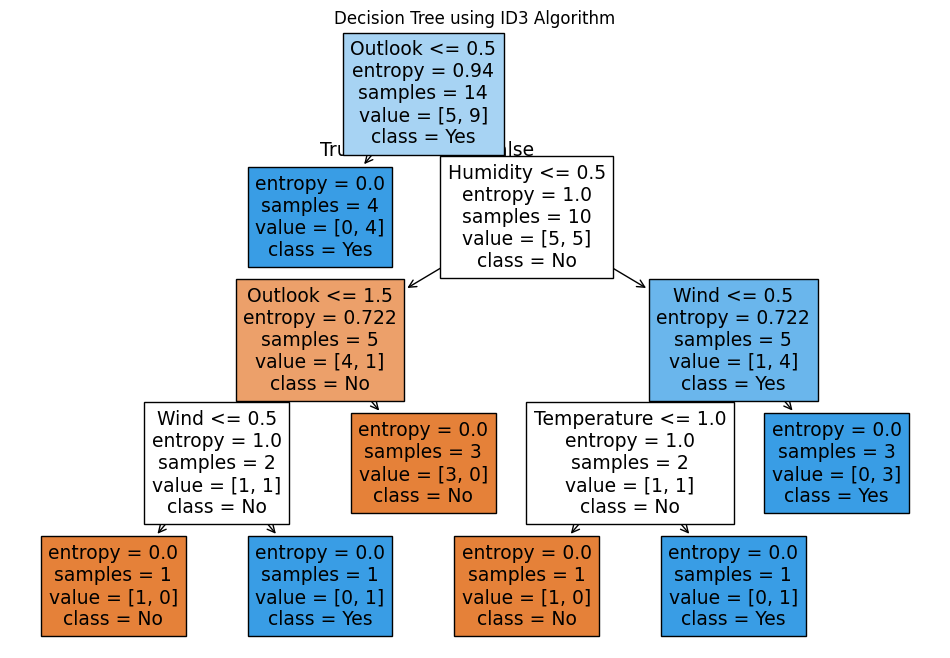


Prediction for New Sample:
Play Tennis = No


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Play Tennis Dataset
data = {
    'Outlook':['Sunny','Sunny','Overcast','Rain','Rain','Rain',
               'Overcast','Sunny','Sunny','Rain','Sunny',
               'Overcast','Overcast','Rain'],

    'Temperature':['Hot','Hot','Hot','Mild','Cool','Cool',
                   'Cool','Mild','Cool','Mild','Mild',
                   'Mild','Hot','Mild'],

    'Humidity':['High','High','High','High','Normal','Normal',
                'Normal','High','Normal','Normal','Normal',
                'High','Normal','High'],

    'Wind':['Weak','Strong','Weak','Weak','Weak','Strong',
            'Strong','Weak','Weak','Weak','Strong',
            'Strong','Weak','Strong'],

    'PlayTennis':['No','No','Yes','Yes','Yes','No',
                  'Yes','No','Yes','Yes','Yes',
                  'Yes','Yes','No']
}

df = pd.DataFrame(data)

print("Dataset:\n")
print(df)

# Label Encoding
encoder = LabelEncoder()

for col in df.columns:
    df[col] = encoder.fit_transform(df[col])

X = df.drop('PlayTennis', axis=1)
y = df['PlayTennis']

# Build Decision Tree using ID3 (Entropy)
model = DecisionTreeClassifier(criterion='entropy', random_state=42)
model.fit(X, y)

# Plot Decision Tree
plt.figure(figsize=(12,8))
plot_tree(model,
          feature_names=['Outlook','Temperature','Humidity','Wind'],
          class_names=['No','Yes'],
          filled=True)

plt.title("Decision Tree using ID3 Algorithm")
plt.show()

# New Sample
# Sunny, Hot, High, Weak
new_sample = [[2, 1, 0, 1]]

prediction = model.predict(new_sample)

print("\nPrediction for New Sample:")
if prediction[0] == 1:
    print("Play Tennis = Yes")
else:
    print("Play Tennis = No")